In [1]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize,sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [2]:
df=pd.read_csv('/content/nlp_dataset.csv')
df

,Text
0,Natural Language Processing is a fascinating f...
1,It bridges the gap between humans and machines...
2,NLP techniques are widely used in applications...
3,Machine translation and speech recognition are...
4,"Despite its advancements, NLP faces challenges..."
5,Continuous research and innovation are improvi...
6,"The potential of NLP is vast, making it essent..."


In [3]:
#download required nltk resources
nltk.download('punkt') #Tokenizer
nltk.download('stopwords') #stopwords
nltk.download('wordnet') # word forlemmatizer
nltk.download('omw-1.4') # lemmatizer data
nltk.download('punkt_tab') # download the punkt_tab data

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [4]:
stop_words=set(stopwords.words('english'))
print(stop_words)
lemmatizer=WordNetLemmatizer()

{'very', 'for', 'himself', 'yourself', "wouldn't", 'out', 'isn', "aren't", 'yours', 'which', 'in', 'into', 'having', "mightn't", "you'll", 'each', 'should', 'we', "i'll", 'such', "he'd", 'hadn', "i'd", 'am', "isn't", 'how', "shouldn't", 'under', "we'll", "hadn't", 'then', 'not', 'ours', 'don', "she'd", 'over', 'while', "needn't", 'both', "doesn't", 'same', 'there', "we'd", 'ma', 'an', "she's", 'so', "we've", 're', 'about', 'but', 'once', 'd', 'just', 'here', 't', 'as', 'itself', 'some', "it'd", 'from', 'and', 'now', 'these', 'my', 'have', 'you', 'themselves', "she'll", "he's", 'more', "didn't", 'down', 'most', 'hers', 'been', "it's", 'wasn', "they're", 'those', "couldn't", 'during', 'nor', "won't", 'the', 'were', 'haven', 'this', 'did', 'whom', 'through', 'will', "shan't", 'his', "hasn't", 'what', 'can', 'i', "i'm", "weren't", "he'll", 'because', 'them', "don't", 'up', 'at', 'myself', 'll', 'or', 'had', 'hasn', 'why', 'no', "that'll", "i've", 'to', 'a', 'he', 'again', 'all', 'if', 'cou

In [5]:
def process_text(text):
  word_tokens=word_tokenize(text)
  filtered_tokens=[word for word in word_tokens if word.lower() not in stop_words]
  lemmatized_tokens=[lemmatizer.lemmatize(word) for word in filtered_tokens]
  return{
      "Orginal_Text":text,
      "Word_Tokens":word_tokens,
      "Filtered_Tokens":filtered_tokens,
      "Lemmatized_Tokens":lemmatized_tokens
  }

# Apply processing on each row of the dataset
results=df['Text'].apply(process_text)

# Convert results to a dataframe
processed_df=pd.DataFrame(results.tolist())

# Display processed dataframe
print(processed_df.head())

# Save processed results to a new csv file
processed_file_path="processed_nlp_dataset.csv"
processed_df.to_csv(processed_file_path,index=False)
print(f"Processed dataset saved to {processed_file_path}")

                                        Orginal_Text  \
0  Natural Language Processing is a fascinating f...   
1  It bridges the gap between humans and machines...   
2  NLP techniques are widely used in applications...   
3  Machine translation and speech recognition are...   
4  Despite its advancements, NLP faces challenges...   

                                         Word_Tokens  \
0  [Natural, Language, Processing, is, a, fascina...   
1  [It, bridges, the, gap, between, humans, and, ...   
2  [NLP, techniques, are, widely, used, in, appli...   
3  [Machine, translation, and, speech, recognitio...   
4  [Despite, its, advancements, ,, NLP, faces, ch...   

                                     Filtered_Tokens  \
0  [Natural, Language, Processing, fascinating, f...   
1  [bridges, gap, humans, machines, enabling, com...   
2  [NLP, techniques, widely, used, applications, ...   
3  [Machine, translation, speech, recognition, co...   
4  [Despite, advancements, ,, NLP, faces, chal

In [6]:
print(results)

0    {'Orginal_Text': 'Natural Language Processing ...
1    {'Orginal_Text': 'It bridges the gap between h...
2    {'Orginal_Text': 'NLP techniques are widely us...
3    {'Orginal_Text': 'Machine translation and spee...
4    {'Orginal_Text': 'Despite its advancements, NL...
5    {'Orginal_Text': 'Continuous research and inno...
6    {'Orginal_Text': 'The potential of NLP is vast...
Name: Text, dtype: object


In [7]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

In [8]:
#sample dataset(you can replace this with ur datset)
text_data=[
    "Natural Language Processing is a fascinating field of Artificial Intelligence.",
    "It bridges the gap between humans and machines by enabling computers to understand human language.",
    "NLP techniques are widely used in applications such as chatbots and sentiment analysis.",
    "Machine translation and speech recognition are common use cases of NLP.",
    "Despite its advancements, NLP faces challenges including ambiguity in language.",
    "Continuous research and innovation are improving NLP rapidly.",
    "The potential of NLP is vast, making it essential in modern technology."
]

In [9]:
#initialize count vectorizer
vectorizer=CountVectorizer()

#fit and transform text data
bow_matrix=vectorizer.fit_transform(text_data)

#convert the bow matrix to a dataframe
bow_df=pd.DataFrame(bow_matrix.toarray(),columns=vectorizer.get_feature_names_out())

#display the bag of words representation
print("Bag of Words Representation:")
print(bow_df)

#save to csv(optional)
bow_df.to_csv("bag of words.csv",index=False)
print("\nBag of Words saved as 'bag_of_words.csv'.")

Bag of Words Representation:
   advancements  ambiguity  analysis  and  applications  are  artificial  as  \
0             0          0         0    0             0    0           1   0   
1             0          0         0    1             0    0           0   0   
2             0          0         1    1             1    1           0   1   
3             0          0         0    1             0    1           0   0   
4             1          1         0    0             0    0           0   0   
5             0          0         0    1             0    1           0   0   
6             0          0         0    0             0    0           0   0   

   between  bridges  ...  techniques  technology  the  to  translation  \
0        0        0  ...           0           0    0   0            0   
1        1        1  ...           0           0    1   1            0   
2        0        0  ...           1           0    0   0            0   
3        0        0  ...          

In [10]:
import nltk
from nltk.stem import WordNetLemmatizer,PorterStemmer
from nltk.tokenize import word_tokenize

In [11]:
#download necessary resources
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [12]:
#initialize lemmatizer and stemmer
lemmatizer=WordNetLemmatizer()
stemmer=PorterStemmer()

In [13]:
#define functions for lemmatization and stemming
def lemmatize_text(Text):
  tokens=word_tokenize(str(Text))
  return ''.join([lemmatizer.lemmatize(word) for word in tokens])
def stem_text(Text):
  tokens=word_tokenize(str(Text))
  return ''.join([stemmer.stem(word) for word in tokens])

#apply lemmatization and stemming
df['lemmatized_text']=df['Text'].apply(lemmatize_text)
df['stemmed_text']=df['Text'].apply(stem_text)

#save the comparison dataset
output_path="lemmatization_vs_stemming.csv"
df.to_csv(output_path,index=False)

#preview the comparison
print(df[['Text','lemmatized_text','stemmed_text']])
print(f"Comparison dataset saved to {output_path}")

                                                Text  \
0  Natural Language Processing is a fascinating f...   
1  It bridges the gap between humans and machines...   
2  NLP techniques are widely used in applications...   
3  Machine translation and speech recognition are...   
4  Despite its advancements, NLP faces challenges...   
5  Continuous research and innovation are improvi...   
6  The potential of NLP is vast, making it essent...   

                                     lemmatized_text  \
0  NaturalLanguageProcessingisafascinatingfieldof...   
1  Itbridgethegapbetweenhumanandmachinebyenabling...   
2  NLPtechniquearewidelyusedinapplicationsuchacha...   
3  Machinetranslationandspeechrecognitionarecommo...   
4  Despiteitadvancement,NLPfacechallengeincluding...   
5  ContinuousresearchandinnovationareimprovingNLP...   
6  ThepotentialofNLPisvast,makingitessentialinmod...   

                                        stemmed_text  
0  naturlanguagprocessisafascinfieldofartificii

WORD CLOUD

In [14]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

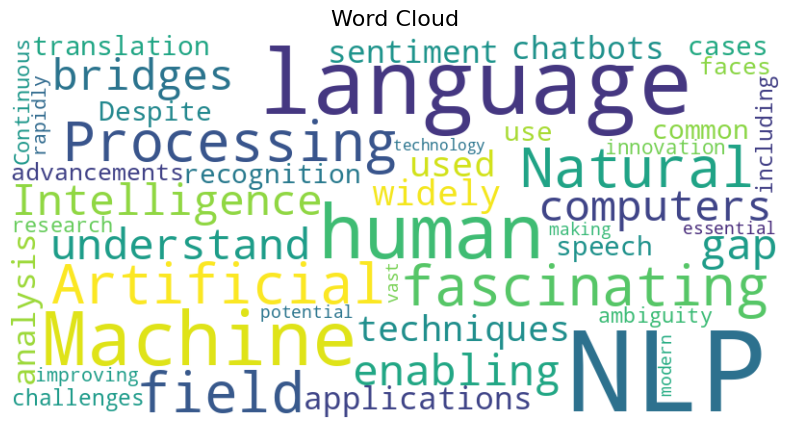

In [15]:
#combine all text from the 'Text' column into a single
text_data=" ".join(df['Text'].dropna())

#generate the word cloud
wordcloud=WordCloud(width=800,height=400,background_color='white').generate(text_data)

#plot the word cloud
plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')

#plt.imshow: This func fromm the matplotlib library is used to display an image in a ply
#Interpolation:Determines how the image pixels are smoothed or blended when scaling
#bilinear:a specific interpolation methos that averages the colors of the four nearesr
plt.axis('off') #remove axis
plt.title("Word Cloud",fontsize=16)
plt.show()